In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.colors as cl
print(cl.CSS4_COLORS)

{'aliceblue': '#F0F8FF', 'antiquewhite': '#FAEBD7', 'aqua': '#00FFFF', 'aquamarine': '#7FFFD4', 'azure': '#F0FFFF', 'beige': '#F5F5DC', 'bisque': '#FFE4C4', 'black': '#000000', 'blanchedalmond': '#FFEBCD', 'blue': '#0000FF', 'blueviolet': '#8A2BE2', 'brown': '#A52A2A', 'burlywood': '#DEB887', 'cadetblue': '#5F9EA0', 'chartreuse': '#7FFF00', 'chocolate': '#D2691E', 'coral': '#FF7F50', 'cornflowerblue': '#6495ED', 'cornsilk': '#FFF8DC', 'crimson': '#DC143C', 'cyan': '#00FFFF', 'darkblue': '#00008B', 'darkcyan': '#008B8B', 'darkgoldenrod': '#B8860B', 'darkgray': '#A9A9A9', 'darkgreen': '#006400', 'darkgrey': '#A9A9A9', 'darkkhaki': '#BDB76B', 'darkmagenta': '#8B008B', 'darkolivegreen': '#556B2F', 'darkorange': '#FF8C00', 'darkorchid': '#9932CC', 'darkred': '#8B0000', 'darksalmon': '#E9967A', 'darkseagreen': '#8FBC8F', 'darkslateblue': '#483D8B', 'darkslategray': '#2F4F4F', 'darkslategrey': '#2F4F4F', 'darkturquoise': '#00CED1', 'darkviolet': '#9400D3', 'deeppink': '#FF1493', 'deepskyblue'

In [3]:
df=pd.read_csv('cardiotocographic.csv')

In [4]:
df.shape

(2126, 14)

In [5]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [7]:
### Checking missing values
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [8]:
(21/2105)*100,(20/2105)*100

(0.9976247030878859, 0.9501187648456058)

In [9]:
### the missing values are more than 5%, hence we can replace these missing values with mean/median/mode
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

In [10]:
df.fillna({'LB':df.LB.mean(),'AC':df.AC.mean(),'DS':df.DS.mean(),'DP':df.DP.mean(),
          'MLTV':df.MLTV.median(),'Width':df.Width.median(),'Tendency':df.Tendency.median(),'NSP':df.NSP.median})

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.0
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.0
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.0


In [11]:
df_dropped=df.dropna()
df_dropped

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [12]:
### to check Duplicates
df.duplicated().sum()

np.int64(2)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
#### Duplicate values are dropped
df.duplicated().sum()

np.int64(0)

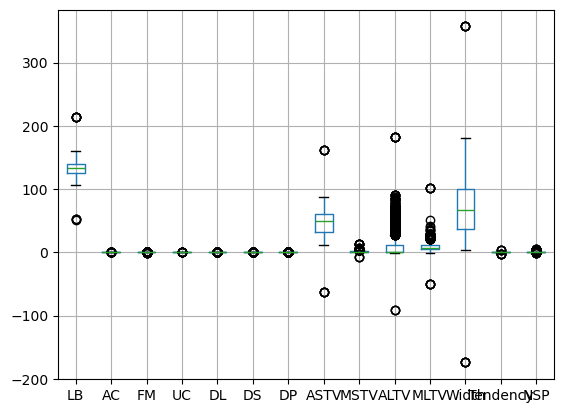

In [15]:
### boxplot to check outliers
df.boxplot()
plt.show()

In [16]:
### outliers are present in the given dataset,hence capping is done so as to remove outliers

In [17]:
def outlier_cappping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)

    IQR= Q3-Q1

    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+1.5*IQR

    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(['int','float']).columns:

    outlier_cappping(df,col)


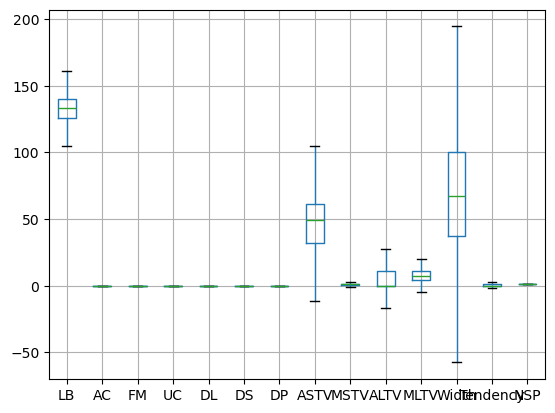

In [18]:
df.boxplot()
plt.show()

###  2 Statistical summary of the dataset

In [19]:
## the describe() gives the statistcal information of hte dataset
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2103.000000,2104.000000,2124.000000,2124.000000,2124.000000,2103.0,2103.0,2124.000000,2124.000000,2124.000000,2103.000000,2103.000000,2103.000000,2103.0
mean,133.291604,0.003149,0.001570,0.004365,0.001772,0.0,0.0,46.998334,1.304554,6.697979,8.017610,70.351685,0.319999,1.0
std,9.976211,0.003851,0.002487,0.003001,0.002670,0.0,0.0,17.609911,0.781303,10.381254,5.094192,39.773195,0.624916,0.0
min,105.000000,-0.008475,-0.003853,-0.005158,-0.004938,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.850000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001858,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001634,0.000000,0.004486,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.486468,0.000000,1.0
75%,140.000000,0.005650,0.002568,0.006536,0.003292,0.0,0.0,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.0
max,161.000000,0.014124,0.006421,0.013552,0.008230,0.0,0.0,104.500000,3.200000,27.500000,20.350000,194.500000,2.500000,1.0


#### Highlight any interesting findings from this summary

1. Large Standard Deviation
Indicates high variability in the data.
Interesting if the data should be uniform (e.g., product prices, student scores).

2. High IQR (Interquartile Range)
Data is widely spread, but not necessarily with outliers. -Check this especially in financial or size-related columns.

3.Low Standard Deviation + Low IQR
Data values are consistent.
Could indicate redundancy or limited usefulness in prediction.


## 3.	Data Visualization:

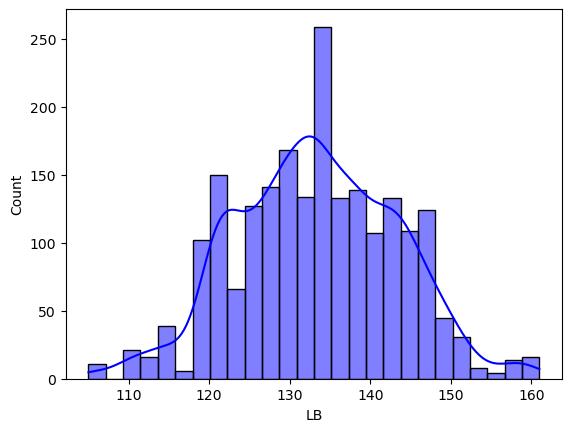

In [20]:
## Histogram plots
sns.histplot(data=df,x='LB',kde=True,color='blue')
plt.show()

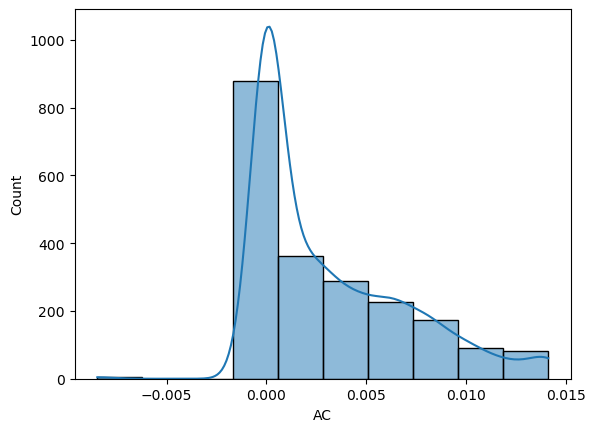

In [21]:
sns.histplot(data=df,x='AC',kde=True,bins=10)
plt.show()

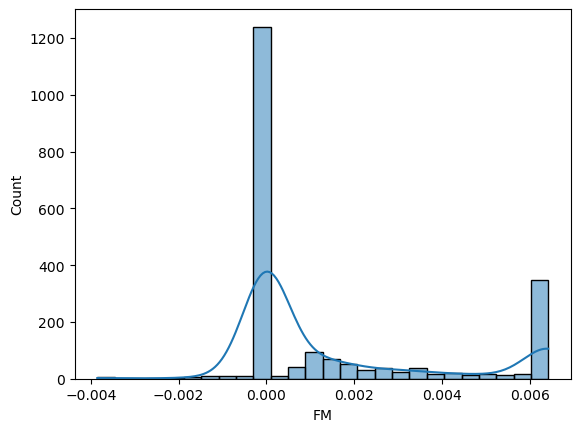

In [22]:
sns.histplot(data=df,x='FM',kde=True)
plt.show()

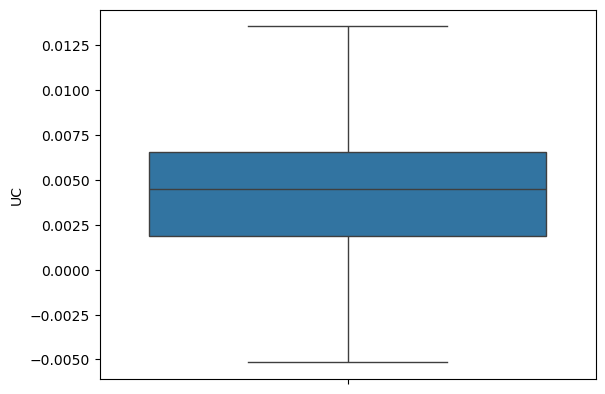

In [23]:
### boxplot(vertical)for numerical variables
sns.boxplot(data=df,y='UC')
plt.show()

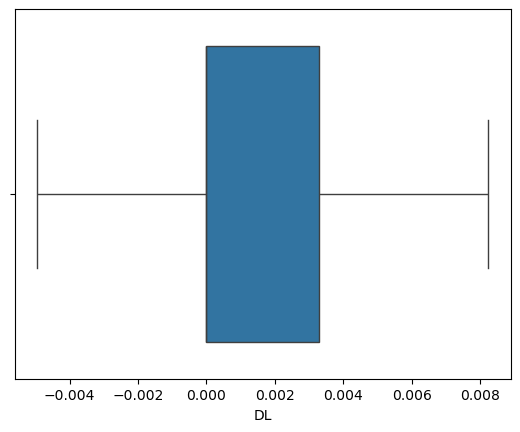

In [24]:
### boxplot(horizontal)for numerical variables
sns.boxplot(data=df,x='DL')
plt.show()

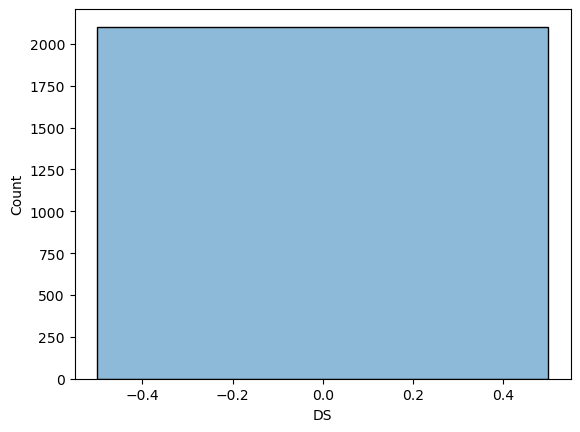

In [25]:
sns.histplot(data=df,x='DS',kde=True)
plt.show()

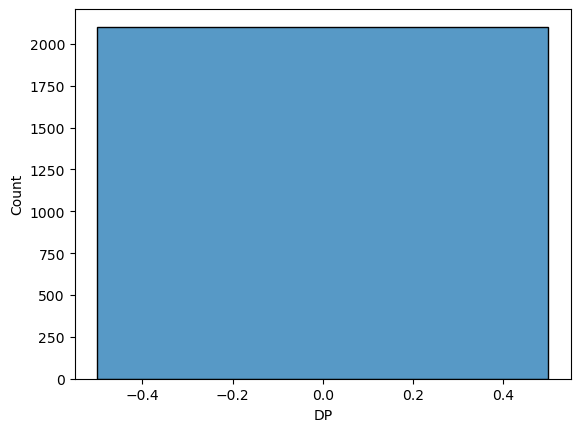

In [26]:
sns.histplot(data=df,x='DP')
plt.show()

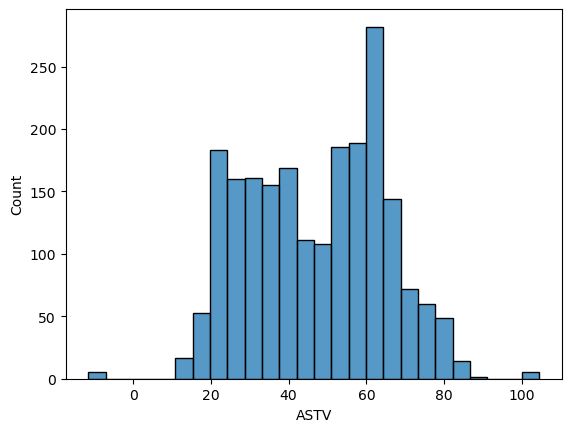

In [27]:
sns.histplot(data=df,x='ASTV')
plt.show()

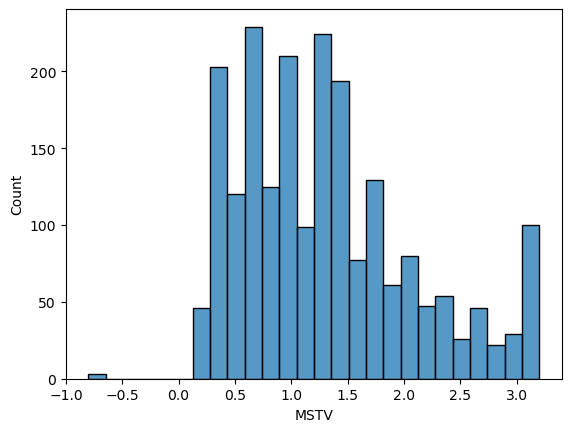

In [28]:
sns.histplot(data=df,x='MSTV')
plt.show()

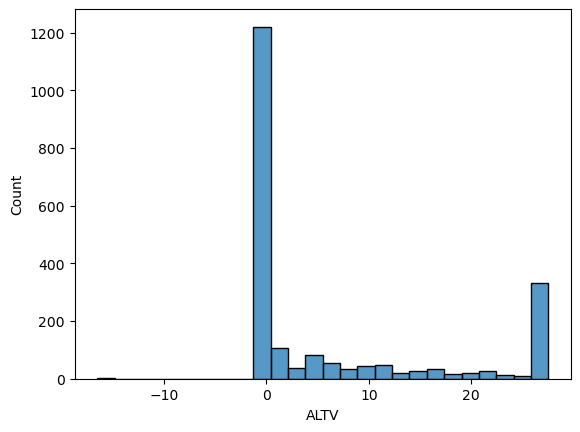

In [29]:
sns.histplot(data=df,x='ALTV')
plt.show()

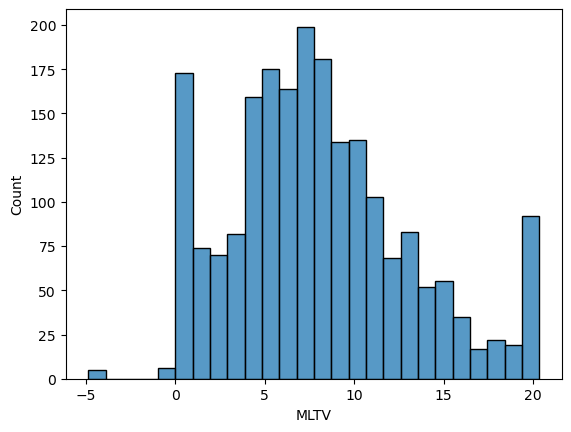

In [30]:
sns.histplot(data=df,x='MLTV')
plt.show()

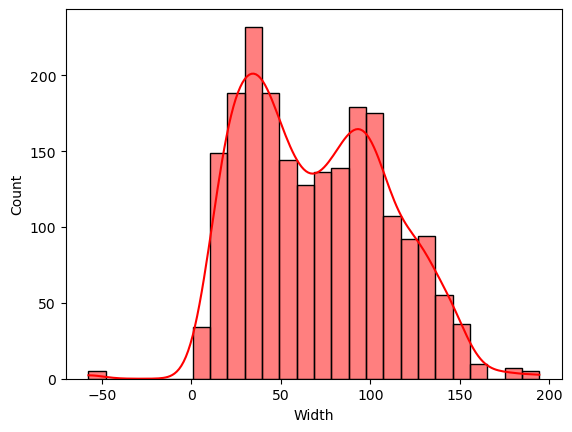

In [31]:
sns.histplot(data=df,x='Width',kde=True,color='Red')
plt.show()

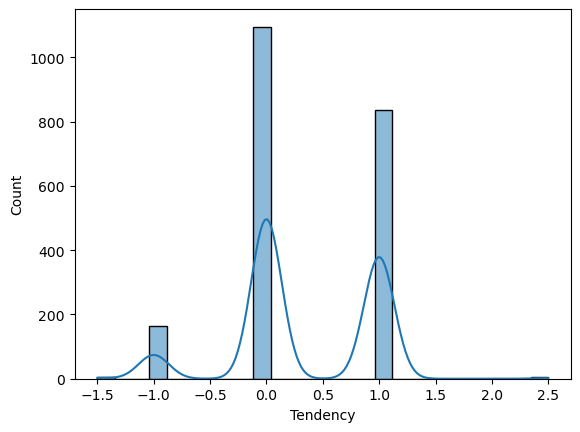

In [32]:
sns.histplot(data=df,x='Tendency',kde=True)
plt.show()

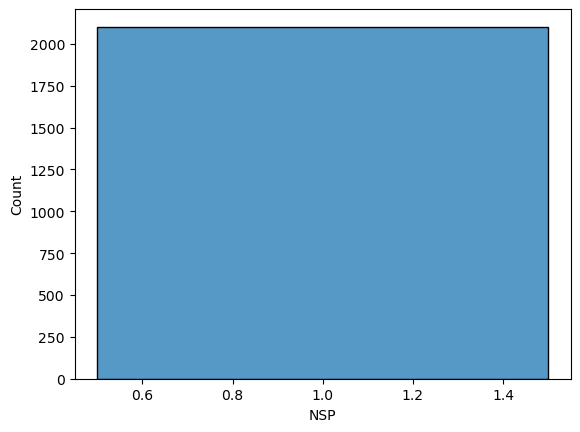

In [33]:
sns.histplot(data=df,x='NSP')
plt.show()

##### Now generating scatter plots or correlation heatmaps to explore relationships between pairs of variables.

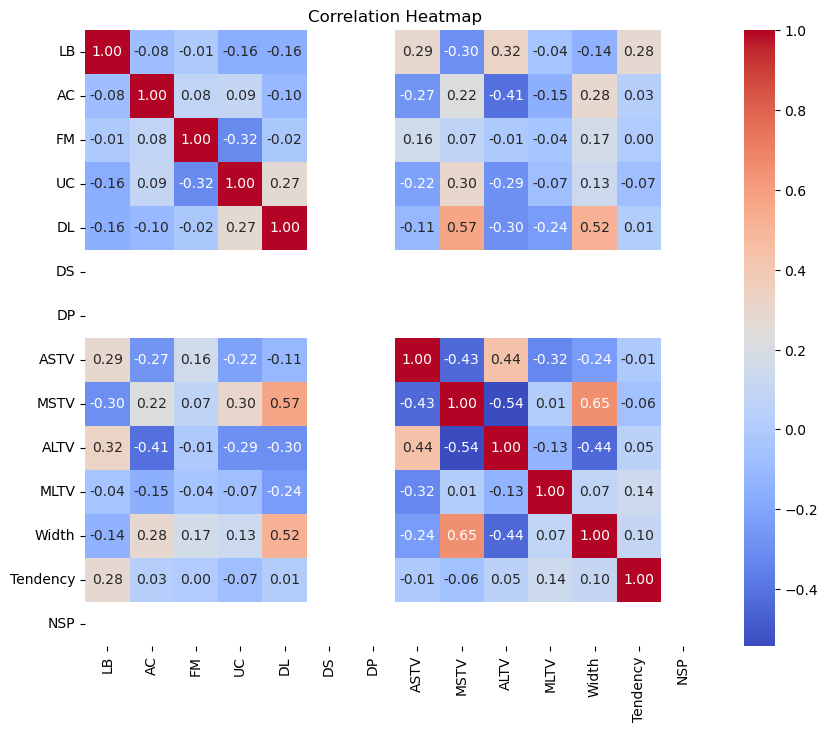

In [36]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'coolwarm', fmt = '0.2f') #for Heatmap 
plt.title('Correlation Heatmap')
plt.show()

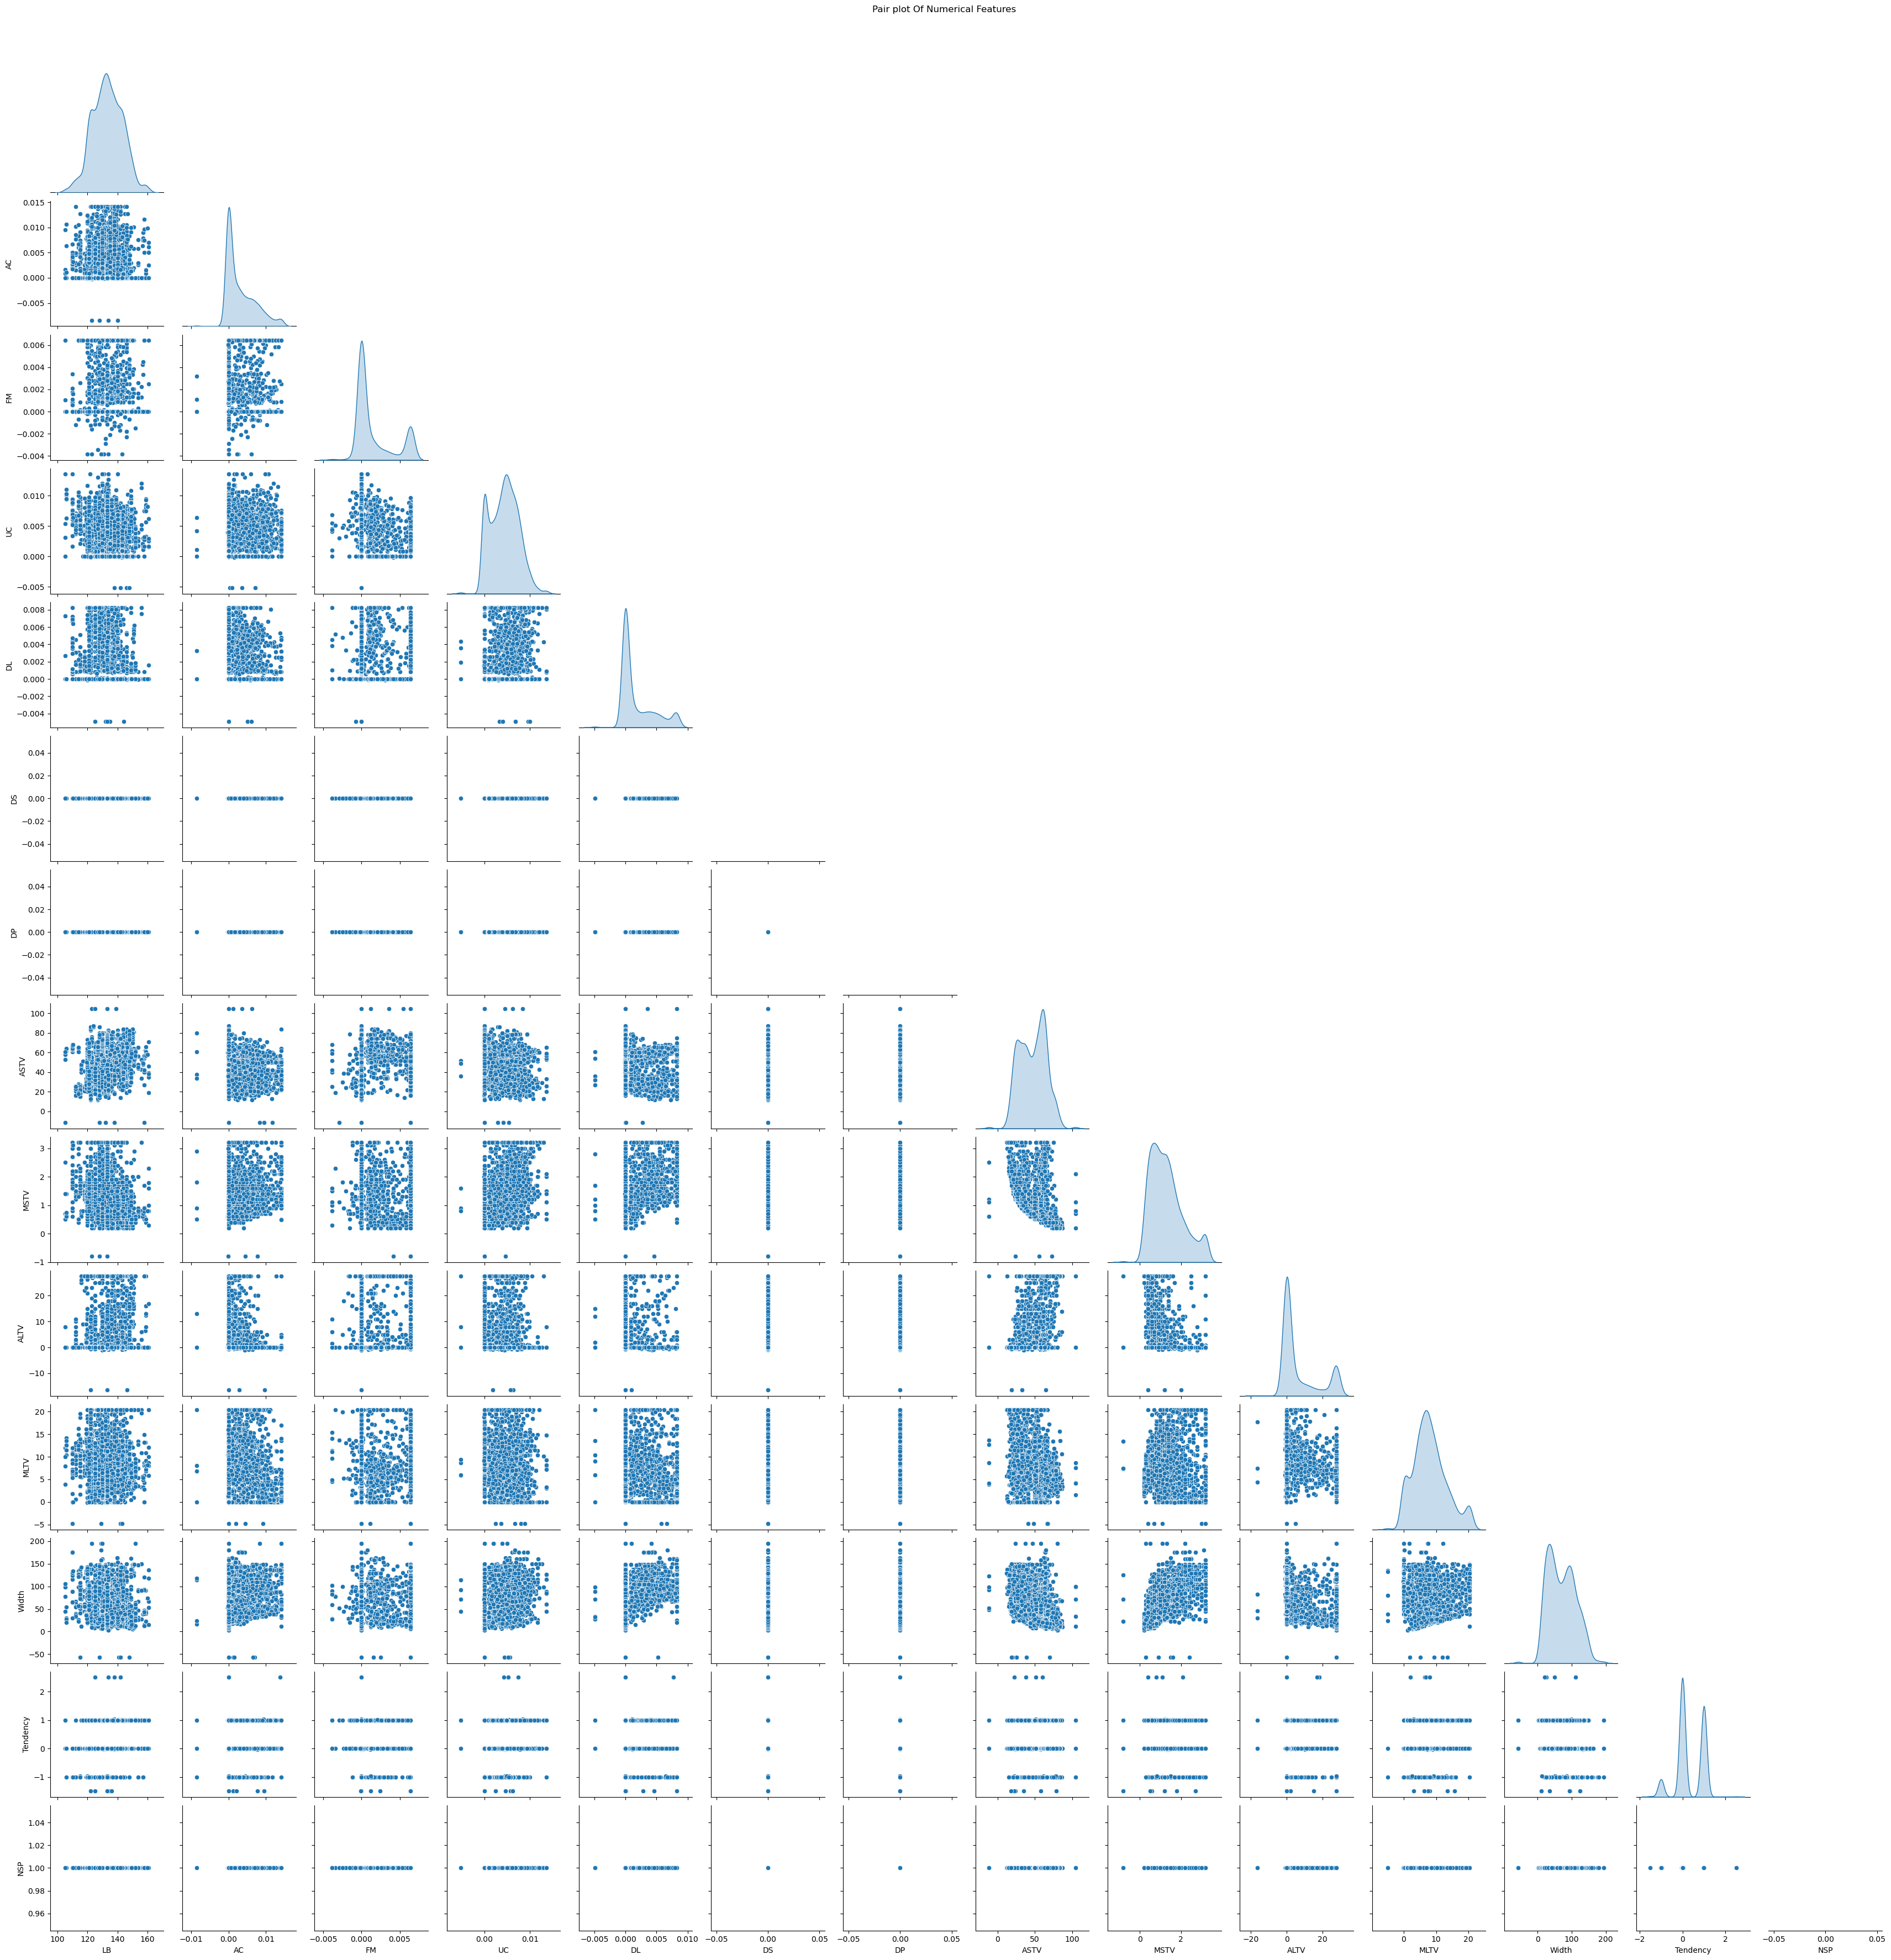

In [38]:
 #### Advanced visualization techniques like pair plots, or violin plots for deeper insights.
sns.pairplot(df, diag_kind = 'kde', corner = True)
plt.suptitle("Pair plot Of Numerical Features", y = 1.02)
plt.show()

#### 4. Pattern Recognition and insights

In [40]:
correlation_matrix = df.corr()
correlation_matrix


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.081715,-0.006859,-0.163765,-0.156858,NaN,NaN,0.286501,-0.297040,0.323777,-0.041651,-0.140008,0.281361,NaN
AC,-0.081715,1.000000,0.076600,0.093536,-0.103370,NaN,NaN,-0.273942,0.219101,-0.410713,-0.151983,0.284221,0.029530,NaN
FM,-0.006859,0.076600,1.000000,-0.318156,-0.018024,NaN,NaN,0.155798,0.070412,-0.013820,-0.036405,0.165220,0.000681,NaN
UC,-0.163765,0.093536,-0.318156,1.000000,0.268151,NaN,NaN,-0.217484,0.298462,-0.294226,-0.072768,0.131470,-0.074464,NaN
DL,-0.156858,-0.103370,-0.018024,0.268151,1.000000,NaN,NaN,-0.112289,0.566625,-0.296383,-0.242131,0.516234,0.014642,NaN
DS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASTV,0.286501,-0.273942,0.155798,-0.217484,-0.112289,NaN,NaN,1.000000,-0.433731,0.438800,-0.324869,-0.243003,-0.010316,NaN
MSTV,-0.297040,0.219101,0.070412,0.298462,0.566625,NaN,NaN,-0.433731,1.000000,-0.541296,0.013248,0.650855,-0.063484,NaN
ALTV,0.323777,-0.410713,-0.013820,-0.294226,-0.296383,NaN,NaN,0.438800,-0.541296,1.000000,-0.133663,-0.441284,0.050687,NaN


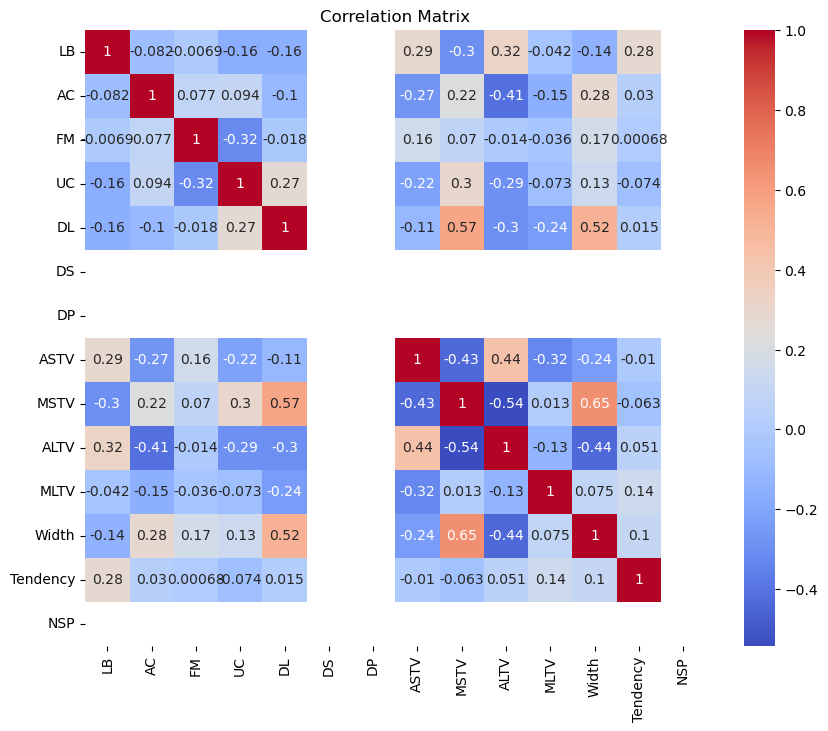

In [41]:
plt.figure(figsize =  (10,8))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()


Clinical Decision-Making: High ASTV with low FHR could signal fetal distress, prompting immediate medical attention.

Predictive Modeling: Highly correlated variables might be redundant — consider dimensionality reduction (e.g., PCA).

Monitoring Tool Optimization: Understanding which features are most informative helps improve CTG monitoring tools.


### Conclusion:
Summarizing  the key insights and patterns discovered through exploratory analysis.

Class Distribution:
The dataset contains three fetal health categories: Normal, Suspect, and Pathological.
The data is slightly imbalanced, with Normal class being the most frequent.

Feature Correlation:
Strong positive correlation observed between variables indicating healthier fetuses show more frequent accelerations.
High correlation between mean value of short-term variability (ASTV) and fetal health status was evident.

Outlier Detection:
Outliers were found in features like uterine contractions, fetal movements, and prolonged decelerations, which may be clinically significant or due to noise in the data collection process.
Appropriate outlier treatment improved data quality without data loss by Capping technique.

Class-wise Trends:
Normal fetuses tend to have:
Higher ASTV and accelerations.
Lower decelerations and variability in heart rate.

Pathological cases showed:
Increased abnormal decelerations and higher percentage of time with abnormal STV.
Distributions and Patterns:
Distributions of features like ASTV, MSTV, and accelerations showed clear separation between Normal and Pathological classes.
Boxplots revealed higher variance in pathological cases, especially in features related to heart rate variability.
Multivariate Analysis:
Pair plots and heatmaps highlighted useful feature clusters and class-separating attributes.
These insights suggest that a combination of specific features (like ASTV and decelerations) could be highly predictive of fetal health.
Clinical Implication:
The EDA suggests that CTG measurements are reliable indicators of fetal well-being.


### Discussing how these findings could impact decision-making or further analyses.
Deliverables:
Enhanced Clinical Decision Support:
The identified patterns—such as low accelerations and high decelerations in pathological cases—can directly support early warning systems for fetal distress.
Obstetricians can use these patterns to decide when to intervene 

Feature Prioritization for Predictive Models:
Features like ASTV, MSTV, accelerations, and prolonged decelerations were found to be most correlated with fetal health outcomes.
These can be prioritized as key inputs in machine learning models for fetal risk classification or outcome prediction.

Risk Stratification:
Based on class-specific trends (Normal, Suspect, Pathological), patients can be categorized into low-risk and high-risk groups.

Data Imbalance Consideration:
Since the dataset is slightly imbalanced, future analyses (e.g., supervised learning) should be implemented with some other accurate models so as to improve reliability 

Outlier Impact Awareness:
Recognizing the impact of outliers in key features ensures cleaner data, leading to more robust diagnostic tools.
This encourages a need for continuous monitoring and data cleaning in real-world CTG applications.

Basis for Further Research:
Findings provide a strong basis for building and validating classification models to automate fetal health assessment.

Policy and Protocol Improvement:
Hospitals and clinics can use these insights to update CTG interpretation protocols, making them more data-driven and consistent across practitioners.